In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alensomaxx/provate/train.csv
/kaggle/input/datasets/alensomaxx/provate/test.csv


In [30]:
import numpy as np #numerical analysis
import pandas as pd # process in a dataframe

import matplotlib.pyplot as plt #plotting graph
import seaborn as sns # advance ploting
 
import matplotlib.image as  mpimg # image processing
from sklearn.model_selection import train_test_split # train test split
from sklearn.metrics import confusion_matrix, classification_report # model performance metrics
from tensorflow.keras.utils import to_categorical # utility function
from tensorflow.keras.models import Sequential # sequental model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout #layers

#import keras.optimizers import RMSprop
#from keras.preprocessing.image import ImageDataGenerator
#from keras.callbacks import ReduceLROnPlateau

In [31]:
#read the data
train = pd.read_csv('/kaggle/input/datasets/alensomaxx/provate/train.csv')
test = pd.read_csv('/kaggle/input/datasets/alensomaxx/provate/test.csv')

In [32]:
train.describe()


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [33]:
train['label'].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

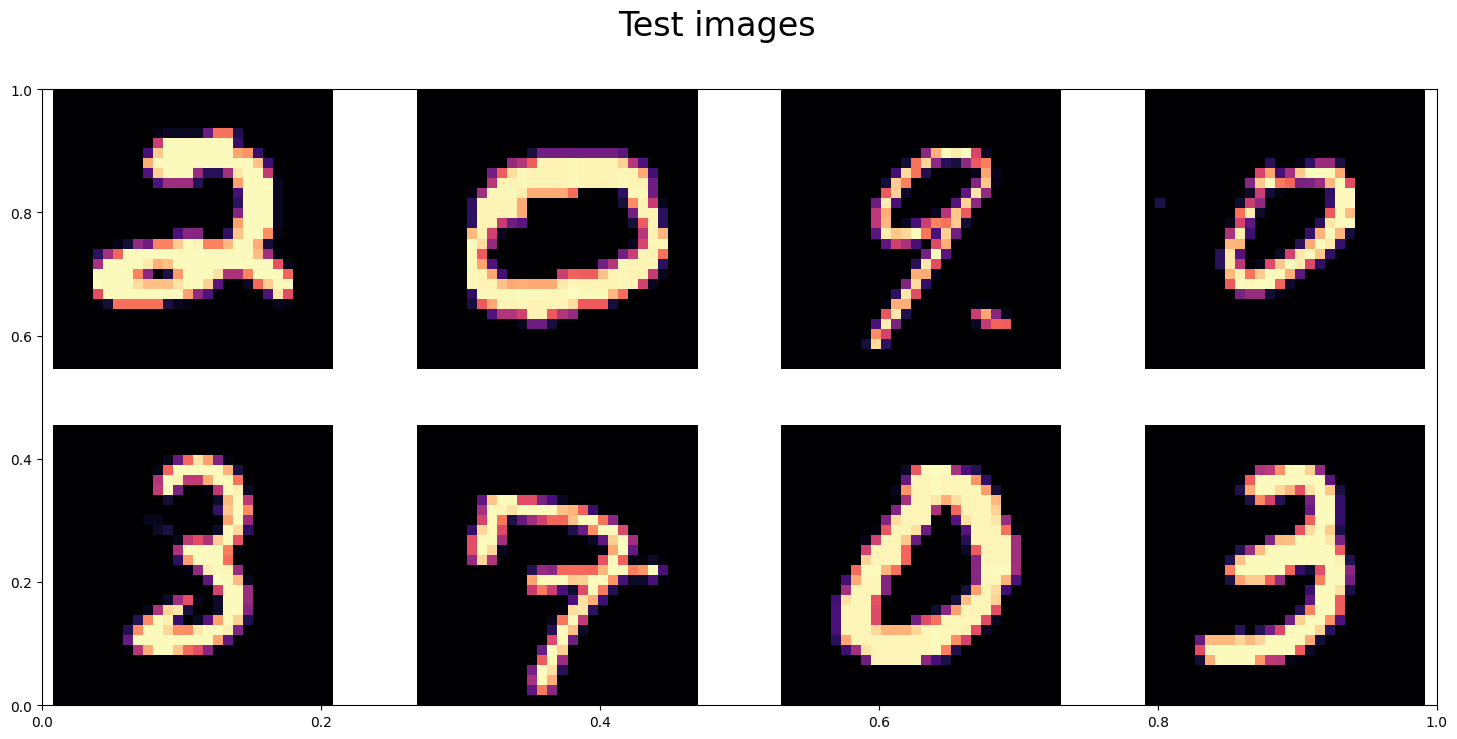

In [34]:
fig,ax = plt.subplots(figsize=(18, 8))
for ind, row in test.iloc[:8, :].iterrows():
    plt.subplot(2,4, ind+1)
    img = row.to_numpy()[:].reshape(28, 28)
    fig.suptitle('Test images', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='magma')

In [36]:
#split into image and labels and convert to numpy array

X = train.iloc[:, 1:].to_numpy()
y = train['label'].to_numpy()

#test dataset
test = test.loc[:, :].to_numpy()

for i in [X, y, test]:
    print(i.shape)

(42000, 784)
(42000,)
(28000, 784)


In [38]:
X = X/255.0
test = test/255.0

In [39]:
#reshape dataset

#shape of training and test datasets

print(X.shape)
print(test.shape)
#reshape the dataframe to 3x3 matric with 1 channel grey scale values
X= X.reshape(-1, 28, 28 ,1)
test = test.reshape(-1,28,28,1)
#shape of treaining and test dataset
print(X.shape)
print(test.shape)

(42000, 784)
(28000, 784)
(42000, 28, 28, 1)
(28000, 28, 28, 1)


In [40]:
#one hot encoding

#shape and values of target

print(y.shape)
print(y[0])

#convert Y_train to categorical by one-hot-encoding
y_enc = to_categorical(y, num_classes = 10)
#shape and value of target
print(y_enc.shape)
print(y_enc[0])

(42000,)
1
(42000, 10)
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [43]:
#train test split 

#random seed
random_seed = 2
# train validation split
X_train, X_val, y_train_enc, y_val_enc = train_test_split(X, y_enc, test_size=0.3)

#shape
for i in [X_train, y_train_enc, X_val, y_val_enc]:
    print(i.shape)

(29400, 28, 28, 1)
(29400, 10)
(12600, 28, 28, 1)
(12600, 10)


[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


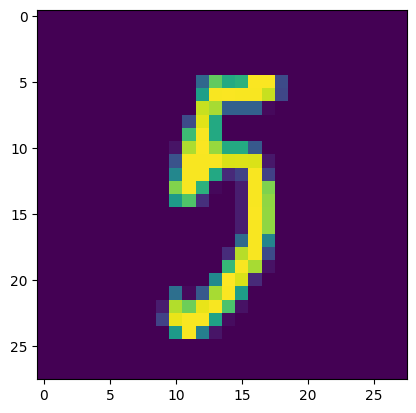

In [46]:
g = plt.imshow(X_train[0][:,:,0])
print(y_train_enc[0])

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


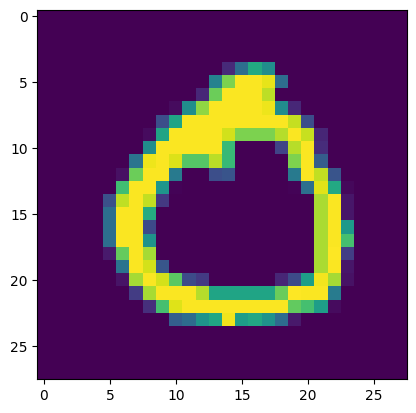

In [47]:
g = plt.imshow(X_train[9][:,:,0])
print(y_train_enc[9])

In [45]:
#CNN Model Prarmeter

INPUT_SHAPE = (28,28,1)
OUTPUT_SHAPE = 10
BATCH_SIZE = 128
EPOCH = 10
VERBOSE = 2

In [ ]:
#define CNN model
model = Sequential()